# GreenSense: Environmental Sensing System for Optimal Plant Selection

### Predicting Crops From Analyzing Soil and Environmental Factors


## > Importing Libraries & Initial Setup

---


In [7]:
import pandas as pd
import numpy as np
import warnings
import random
import math

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import (StandardScaler, OneHotEncoder, RobustScaler,
                                   MultiLabelBinarizer, FunctionTransformer)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.feature_selection import RFECV
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV

from sklearn.multiclass import OneVsRestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.base import BaseEstimator, TransformerMixin

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import catboost as cb
from skmultilearn.model_selection import IterativeStratification

from sklearn.metrics import (accuracy_score, hamming_loss, f1_score,
                             precision_score, recall_score, classification_report,
                             confusion_matrix, multilabel_confusion_matrix)
from sklearn.multioutput import MultiOutputClassifier

from xgboost import XGBRanker
from sklearn.metrics import label_ranking_average_precision_score

import joblib
import time

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Imports Done !")

Imports Done !


---
---


# > Synthetic Data Generation Based On Research Parameters

---


In [8]:
# ============================================================
# 1) FEATURE-DRIVEN MULTI-LABEL CROP SELECTOR
# ============================================================

def weighted_crop_selector(profile, features):
    """
    Given district profile + sensor features,
    returns 1–3 crops with probabilities.
    """

    crops = profile["crops"]
    weights = {crop: 1.0 for crop in crops}  # base weight

    # Extract features
    temp = features["Env_Temp"]
    humid = features["DHT_Humidity"]
    moisture = features["Soil_Moisture"]
    pH = features["pH"]
    N = features["N"]
    P = features["P"]
    K = features["K"]
    alt = features["BMP_Altitude"]
    season = features["season"]
    district = profile["district"]

    # -----------------------------------------
    # TEMPERATURE EFFECTS
    # -----------------------------------------
    if temp > 32:
        for c in ["Mango", "Banana"]:
            weights[c] = weights.get(c, 0) + 3
    if temp < 18:
        for c in ["Wheat", "Onion"]:
            weights[c] = weights.get(c, 0) + 3

    # -----------------------------------------
    # SOIL MOISTURE EFFECTS
    # -----------------------------------------
    if moisture > 75:  # Monsoon / waterlogged crops
        for c in ["Rice", "Finger Millet", "Vari", "Coconut"]:
            weights[c] = weights.get(c, 0) + 4

    if moisture < 30:
        for c in ["Groundnut", "Maize", "Bajra"]:
            weights[c] = weights.get(c, 0) + 4

    # -----------------------------------------
    # HUMIDITY EFFECTS
    # -----------------------------------------
    if humid > 85:
        for c in ["Rice", "Coconut", "Arecanut"]:
            weights[c] = weights.get(c, 0) + 3

    # -----------------------------------------
    # pH EFFECTS
    # -----------------------------------------
    if pH < 6:
        for c in ["Cashew", "Coconut"]:
            weights[c] = weights.get(c, 0) + 2

    if 7 <= pH <= 8:
        for c in ["Grapes", "Onion", "Tomato"]:
            weights[c] = weights.get(c, 0) + 4

    # -----------------------------------------
    # NUTRIENT EFFECTS
    # -----------------------------------------
    if N > 260:
        for c in ["Rice", "Wheat"]:
            weights[c] = weights.get(c, 0) + 2

    if K > 250:
        for c in ["Grapes", "Sugarcane"]:
            weights[c] = weights.get(c, 0) + 3

    # -----------------------------------------
    # ALTITUDE EFFECTS
    # -----------------------------------------
    if alt > 550:
        for c in ["Grapes", "Finger Millet", "Vegetables"]:
            weights[c] = weights.get(c, 0) + 3

    # -----------------------------------------
    # SEASON EFFECTS
    # -----------------------------------------
    if season == "Monsoon":
        for c in ["Rice", "Finger Millet"]:
            weights[c] = weights.get(c, 0) + 3

    if season == "Winter":
        for c in ["Wheat", "Onion"]:
            weights[c] = weights.get(c, 0) + 3

    if season == "Summer":
        for c in ["Mango", "Sugarcane"]:
            weights[c] = weights.get(c, 0) + 3

    # -----------------------------------------
    # Normalize and choose final crops
    # -----------------------------------------
    crop_list = list(weights.keys())
    crop_weights = np.array(list(weights.values()), dtype=float)

    crop_weights = np.maximum(crop_weights, 0.01)  # avoid zeros
    crop_weights = crop_weights / crop_weights.sum()

    # choose 1–3 crops
    num_crops = np.random.choice([1,2,3], p=[0.7, 0.2, 0.1])

    selected = np.random.choice(
        crop_list,
        size=num_crops,
        replace=False,
        p=crop_weights
    )

    return ", ".join(selected)



# ============================================================
# 2) MAIN SYNTHETIC DATA GENERATOR
# ============================================================

def generate_realistic_agri_data(
    num_rows=2500,
    noise_level=0.05,
    null_fraction=0.04,
    all_null_rows_fraction=0.005,
    half_null_rows_fraction=0.01,
    anomaly_rate=0.02,
    extreme_outlier_rate=0.005,
    seed=None
):

    if seed is not None:
        np.random.seed(seed)
        random.seed(seed)

    # PROFILES
    profiles = [
        {
            "district": "Raigad",
            "location": "Karjat",
            "altitude_range": (50, 65),
            "pressure_range": (1004, 1008),
            "ph_range": (5.5, 6.0),
            "n_dist": {"mean": 270, "std": 25},
            "p_dist": {"mean": 8, "std": 2},
            "k_dist": {"mean": 220, "std": 20},
            "annual_temp_range": (16, 38),
            "base_temp": 27.5,
            "monsoon_humidity_range": (85, 98),
            "crops": ["Rice", "Ragi", "Vari", "Mango", "Cashew", "Coconut", "Green Gram"],
        },
        {
            "district": "Raigad",
            "location": "Alibag/Mangaon",
            "altitude_range": (5, 15),
            "pressure_range": (1008, 1012),
            "ph_range": (5.5, 6.2),
            "n_dist": {"mean": 285, "std": 30},
            "p_dist": {"mean": 10, "std": 3},
            "k_dist": {"mean": 230, "std": 25},
            "annual_temp_range": (18, 36),
            "base_temp": 27,
            "monsoon_humidity_range": (90, 98),
            "crops": ["Rice", "Coconut", "Arecanut", "Mango", "Cashew", "Banana"],
        },
        {
            "district": "Nashik",
            "location": "Niphad/Yeola",
            "altitude_range": (560, 580),
            "pressure_range": (945, 955),
            "ph_range": (7.0, 7.8),
            "n_dist": {"mean": 230, "std": 25},
            "p_dist": {"mean": 25, "std": 5},
            "k_dist": {"mean": 270, "std": 30},
            "annual_temp_range": (10, 42),
            "base_temp": 27.5,
            "monsoon_humidity_range": (70, 85),
            "crops": ["Grapes", "Onion", "Pomegranate", "Sugarcane", "Tomato", "Wheat"],
        },
        {
            "district": "Nashik",
            "location": "Baglan/Kalwan",
            "altitude_range": (450, 600),
            "pressure_range": (945, 960),
            "ph_range": (6.8, 7.5),
            "n_dist": {"mean": 220, "std": 30},
            "p_dist": {"mean": 45, "std": 8},
            "k_dist": {"mean": 250, "std": 25},
            "annual_temp_range": (14, 42),
            "base_temp": 27.5,
            "monsoon_humidity_range": (75, 90),
            "crops": ["Onion", "Maize", "Bajra", "Grapes", "Mango", "Soybean", "Groundnut"],
        },
        {
            "district": "Nashik",
            "location": "Igatpuri (Ghat Zone)",
            "altitude_range": (600, 900),
            "pressure_range": (940, 950),
            "ph_range": (6.0, 7.0),
            "n_dist": {"mean": 250, "std": 35},
            "p_dist": {"mean": 15, "std": 4},
            "k_dist": {"mean": 180, "std": 30},
            "annual_temp_range": (13, 38),
            "base_temp": 25,
            "monsoon_humidity_range": (85, 100),
            "crops": ["Rice", "Finger Millet", "Maize", "Vegetables"],
        },
    ]

    records = []
    anomaly_flags = []

    # ============================================================
    # GENERATE ROWS
    # ============================================================
    for _ in range(num_rows):

        profile = random.choice(profiles)
        day_of_year = random.randint(1,365)

        # ----------- Seasonal temperature ----------
        temp_amp = (profile['annual_temp_range'][1] -
                   profile['annual_temp_range'][0]) / 2
        env_temp = profile['base_temp'] + temp_amp * math.sin(math.radians(day_of_year - 90))

        # ----------- Season classification ----------
        if 60 <= day_of_year <= 150:
            season = "Summer"
            humidity = np.random.uniform(20,45)
            light = np.random.uniform(90000,115000)
            soil_moist = np.random.uniform(10,30)
        elif 151 <= day_of_year <= 273:
            season = "Monsoon"
            humidity = np.random.uniform(*profile['monsoon_humidity_range'])
            light = np.random.uniform(15000,55000)
            soil_moist = np.random.uniform(80,98)
        else:
            season = "Winter"
            humidity = np.random.uniform(40,65)
            light = np.random.uniform(60000,90000)
            soil_moist = np.random.uniform(30,55)

        # Irrigated districts
        if profile["district"] == "Nashik" and season != "Monsoon":
            soil_moist = max(soil_moist, np.random.uniform(40,65))

        # RAW SENSOR VALUES
        altitude = np.random.uniform(*profile["altitude_range"])
        pressure = np.random.uniform(*profile["pressure_range"])
        co2 = np.random.uniform(405,425)
        co = np.random.uniform(0.1,5)
        nh3 = np.random.uniform(0.1,4)
        pH = np.random.uniform(*profile["ph_range"])
        N = abs(np.random.normal(profile['n_dist']['mean'], profile['n_dist']['std']))
        P = abs(np.random.normal(profile['p_dist']['mean'], profile['p_dist']['std']))
        K = abs(np.random.normal(profile['k_dist']['mean'], profile['k_dist']['std']))
        soil_temp = env_temp - np.random.uniform(1.5,4)

        # ----------- BUILD BASIC RECORD ----------
        base = {
            "Env_Temp": env_temp,
            "BMP_Pressure": pressure,
            "BMP_Altitude": altitude,
            "Light": light,
            "DHT_Humidity": humidity,
            "MQ135_CO2": co2,
            "MQ135_CO": co,
            "MQ135_NH3": nh3,
            "Soil_Moisture": soil_moist,
            "Soil_Temp": soil_temp,
            "pH": pH,
            "N": N,
            "P": P,
            "K": K,
            "district": profile["district"],
            "location": profile["location"],
            "season": season
        }

        # ----------- MULTI-LABEL TARGET BASED ON FEATURES ----------
        target = weighted_crop_selector(profile, base)
        base["target_crops"] = target

        # ----------- Add noise ----------
        for k in ["Env_Temp","BMP_Pressure","BMP_Altitude","Light","DHT_Humidity",
                  "MQ135_CO2","MQ135_CO","MQ135_NH3","Soil_Moisture",
                  "Soil_Temp","pH","N","P","K"]:
            base[k] *= (1 + np.random.normal(0, noise_level))

        # ----------- Sensor anomalies ----------
        if np.random.rand() < anomaly_rate:
            f = random.choice(["MQ135_CO2","Light","N","Env_Temp"])
            if f == "MQ135_CO2":
                base[f] = np.random.uniform(250,2000)
            elif f == "Light":
                base[f] = np.random.uniform(200000,800000)
            elif f == "N":
                base[f] = random.choice([0, -abs(np.random.uniform(1,100))])
            elif f == "Env_Temp":
                base[f] = np.random.uniform(-20,60)

        # ----------- Extreme outliers ----------
        if np.random.rand() < extreme_outlier_rate:
            f = random.choice(["P","K","BMP_Altitude"])
            base[f] *= np.random.uniform(5,25)

        records.append(base)

    df = pd.DataFrame(records)

    # ----------- RANDOM NULLS ----------
    mask = np.random.rand(*df.shape) < null_fraction
    mask[:, df.columns.get_loc("target_crops")] = False   # NEVER null target
    df = df.mask(mask)

    # ----------- ALL-NULL ROWS (except target) ----------
    for _ in range(int(all_null_rows_fraction * num_rows)):
        idx = np.random.randint(len(df))
        row_cols = [c for c in df.columns if c != "target_crops"]
        df.loc[idx, row_cols] = np.nan

    # ----------- HALF-NULL ROWS ----------
    for _ in range(int(half_null_rows_fraction * num_rows)):
        idx = np.random.randint(len(df))
        safe = [c for c in df.columns if c != "target_crops"]
        drop_cols = np.random.choice(safe, size=int(len(safe)*0.55), replace=False)
        df.loc[idx, drop_cols] = np.nan

    return df.reset_index(drop=True)



df_sample = generate_realistic_agri_data(
    num_rows=np.random.randint(5200, 7000),
    noise_level=0.05,
    null_fraction=0.05,
    all_null_rows_fraction=0.01,
    half_null_rows_fraction=0.01,
    anomaly_rate=0.02,
    extreme_outlier_rate=0.005,
    seed=42
)

df_sample.to_csv("synthetic_crop_data.csv", index=False)

df = df_sample.copy()
print("Synthetic data generated and saved to 'synthetic_crop_data.csv'")

Synthetic data generated and saved to 'synthetic_crop_data.csv'


## > Data Loading

---


In [9]:
# dataset_id = "1gcT3BLkUZNoM5sTnvazYJ0ecaGaVXh1D"

# url = f"https://drive.google.com/uc?id={dataset_id}"

# df = pd.read_csv(url)
# print(f"Loaded dataframe with shape: {df.shape}")

---
---


## > Exploratory Data Analysis (EDA)

---

### > Tabular EDA

---


In [10]:
print("### Dataframe Info ###")
df.info()

### Dataframe Info ###
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6326 entries, 0 to 6325
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Env_Temp       5935 non-null   float64
 1   BMP_Pressure   5922 non-null   float64
 2   BMP_Altitude   5897 non-null   float64
 3   Light          5948 non-null   float64
 4   DHT_Humidity   5955 non-null   float64
 5   MQ135_CO2      5918 non-null   float64
 6   MQ135_CO       5925 non-null   float64
 7   MQ135_NH3      5935 non-null   float64
 8   Soil_Moisture  5922 non-null   float64
 9   Soil_Temp      5945 non-null   float64
 10  pH             5925 non-null   float64
 11  N              5894 non-null   float64
 12  P              5914 non-null   float64
 13  K              5920 non-null   float64
 14  district       5922 non-null   object 
 15  location       5898 non-null   object 
 16  season         5927 non-null   object 
 17  target_crops   6326 non-null 

In [11]:
X_df = df.drop(columns=["target_crops"])
y_df = df["target_crops"]

print("\n### Descriptive Statistics for Features ###")
X_df.describe().T


### Descriptive Statistics for Features ###


,count,mean,std,min,25%,50%,75%,max
Env_Temp,5935.0,26.730094,9.406758,-17.580021,18.417381,26.557074,35.058944,59.736300
BMP_Pressure,5922.0,973.704870,56.231986,776.184987,934.887066,972.640007,1012.187558,1181.951509
BMP_Altitude,5897.0,390.752058,393.424026,4.597404,53.650057,517.467368,596.527086,11233.957722
Light,5948.0,70333.843542,43673.133492,13665.602199,43775.358240,71289.954638,90116.072275,785585.418898
DHT_Humidity,5955.0,59.586772,23.151849,18.568653,41.622466,55.378980,82.265679,110.523574
MQ135_CO2,5918.0,418.822943,63.007916,283.339954,401.104216,415.768649,430.075465,1943.551298
MQ135_CO,5925.0,2.559428,1.417136,0.096065,1.333411,2.557295,3.766311,5.522088
MQ135_NH3,5935.0,2.047653,1.133039,0.090356,1.058815,2.059642,3.011023,4.483939
Soil_Moisture,5922.0,60.514582,23.775527,9.653508,44.403554,55.408411,84.577898,112.997912
Soil_Temp,5945.0,24.003287,9.297718,7.102142,15.773438,23.805896,32.256529,45.858040


In [12]:
print("\n### Missing Values Counts ###")
print(X_df.isnull().sum())


### Missing Values Counts ###
Env_Temp         391
BMP_Pressure     404
BMP_Altitude     429
Light            378
DHT_Humidity     371
MQ135_CO2        408
MQ135_CO         401
MQ135_NH3        391
Soil_Moisture    404
Soil_Temp        381
pH               401
N                432
P                412
K                406
district         404
location         428
season           399
dtype: int64


### > Graphical EDA

---


In [13]:
numeric_cols = [
    'Env_Temp',
    'BMP_Pressure',
    'BMP_Altitude',
    'Light',
    'DHT_Humidity',
    'MQ135_CO2',
    'MQ135_CO',
    'MQ135_NH3',
    'Soil_Moisture',
    'Soil_Temp',
    'pH',
    'N',
    'P',
    'K'
]
cat_cols = [c for c in df.columns if c not in numeric_cols]

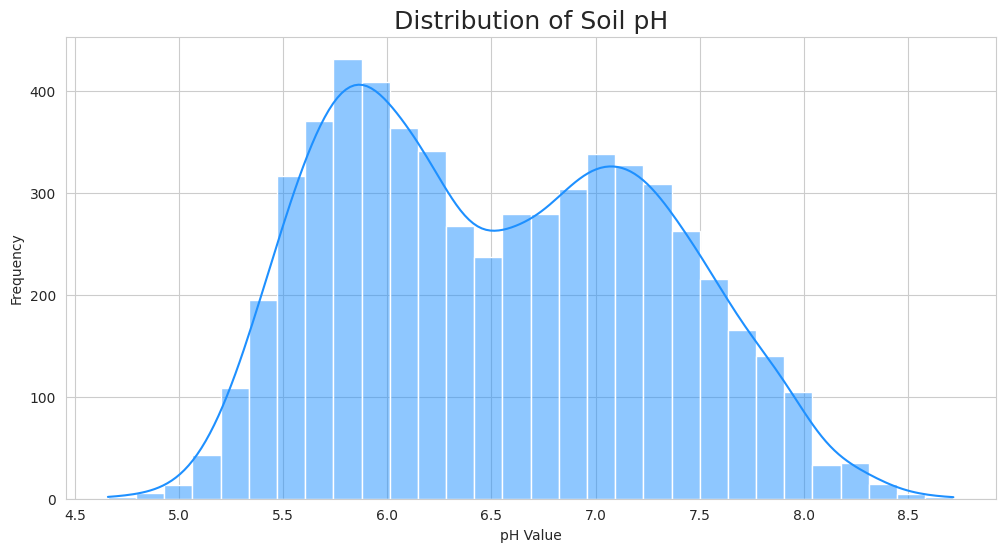

In [14]:
# Graph 1: Distribution of a Key Numerical Feature (e.g., pH)
plt.figure(figsize=(12, 6))
sns.histplot(df['pH'].dropna(), kde=True, bins=30, color='dodgerblue')
plt.title('Distribution of Soil pH', fontsize=18)
plt.xlabel('pH Value')
plt.ylabel('Frequency')
plt.show()

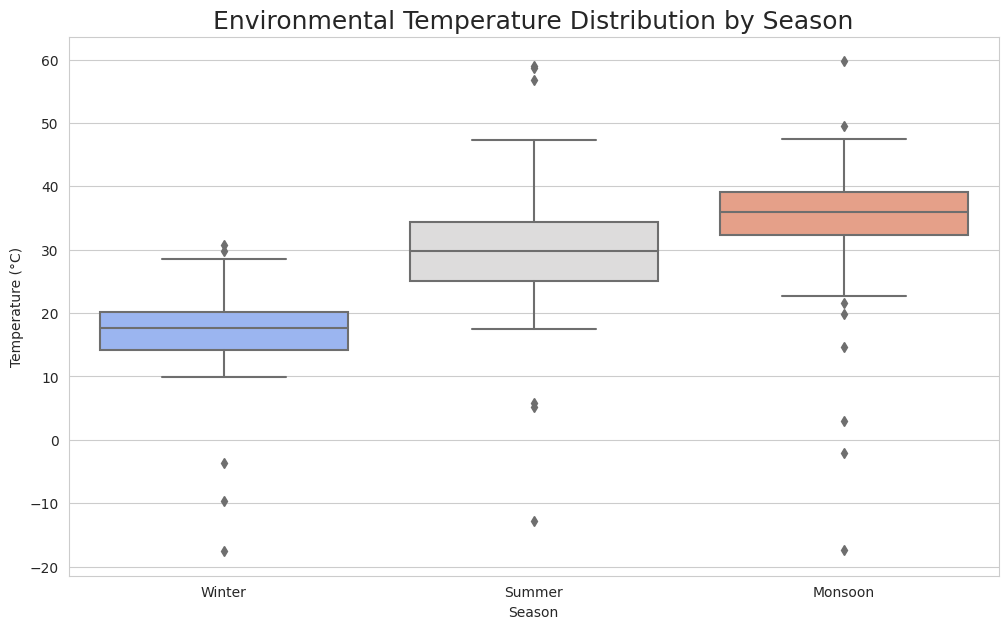

In [15]:
# Graph 2: Distribution of Environmental Temperature by Season
plt.figure(figsize=(12, 7))
sns.boxplot(x='season', y='Env_Temp', data=df, palette='coolwarm')
plt.title('Environmental Temperature Distribution by Season', fontsize=18)
plt.xlabel('Season')
plt.ylabel('Temperature (°C)')
plt.show()

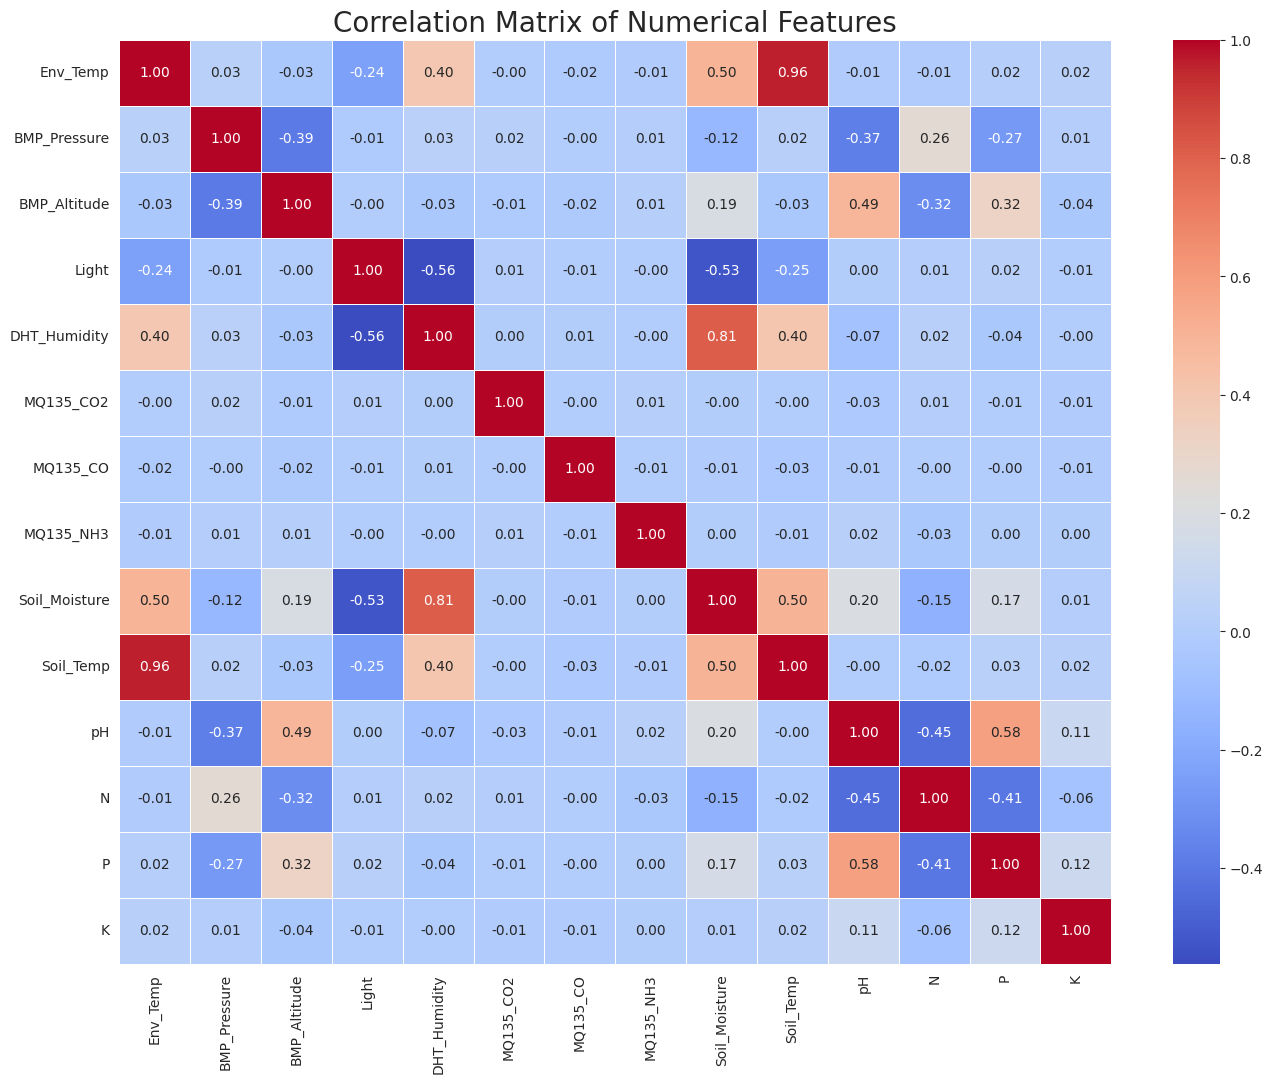

In [ ]:
# Graph 3: Correlation Heatmap of Numerical Features
plt.figure(figsize=(16, 12))
numerical_cols = df.select_dtypes(include=np.number).columns
corr_matrix = df[numerical_cols].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Correlation Matrix of Numerical Features', fontsize=20)
plt.show()

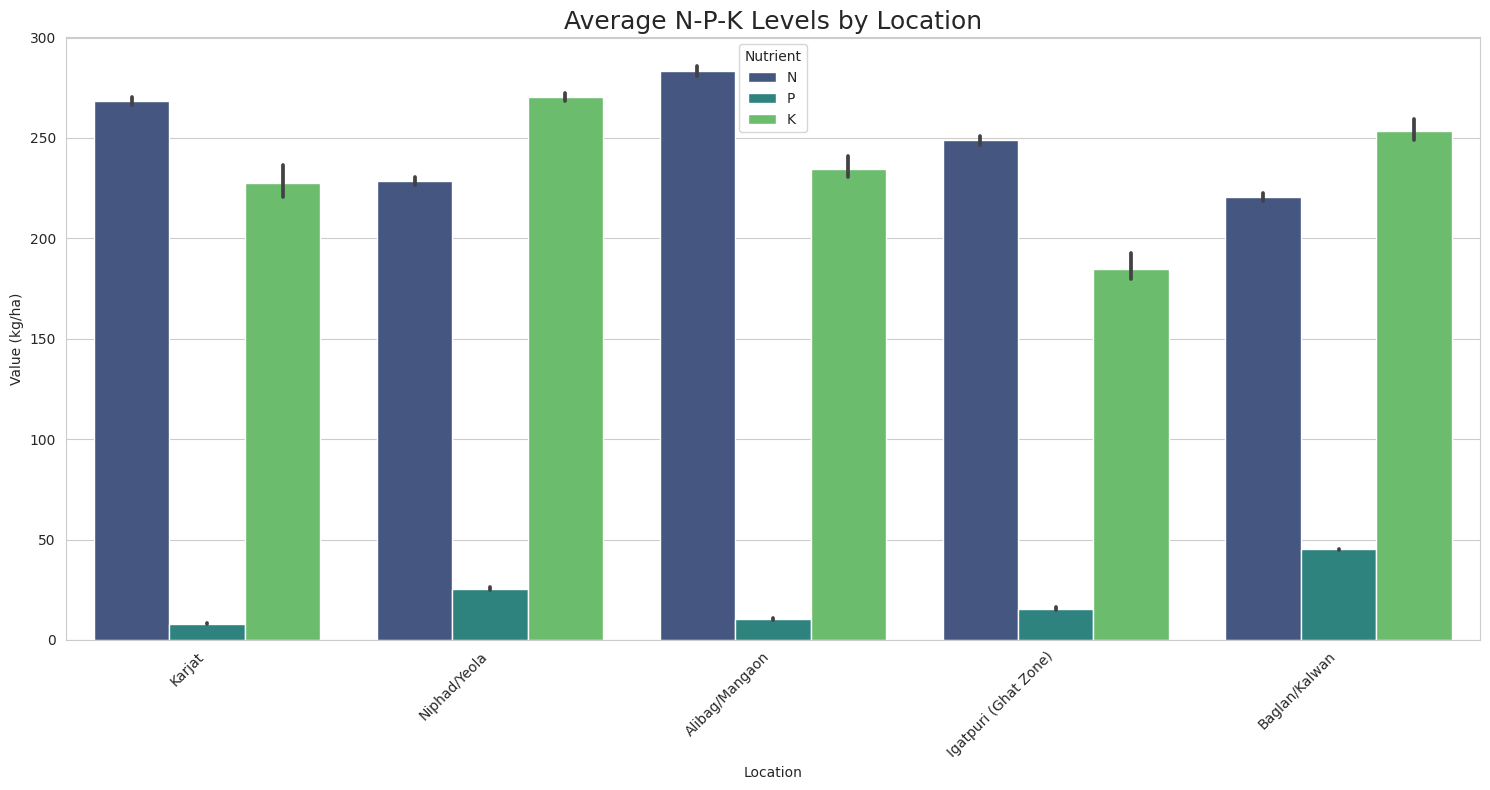

In [ ]:
# Graph 4: N, P, K values by Location
plt.figure(figsize=(15, 8))
df_melted = df.melt(id_vars='location', value_vars=['N', 'P', 'K'],
                    var_name='Nutrient', value_name='Value')
sns.barplot(x='location', y='Value', hue='Nutrient',
            data=df_melted, palette='viridis')
plt.title('Average N-P-K Levels by Location', fontsize=18)
plt.xlabel('Location')
plt.ylabel('Value (kg/ha)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

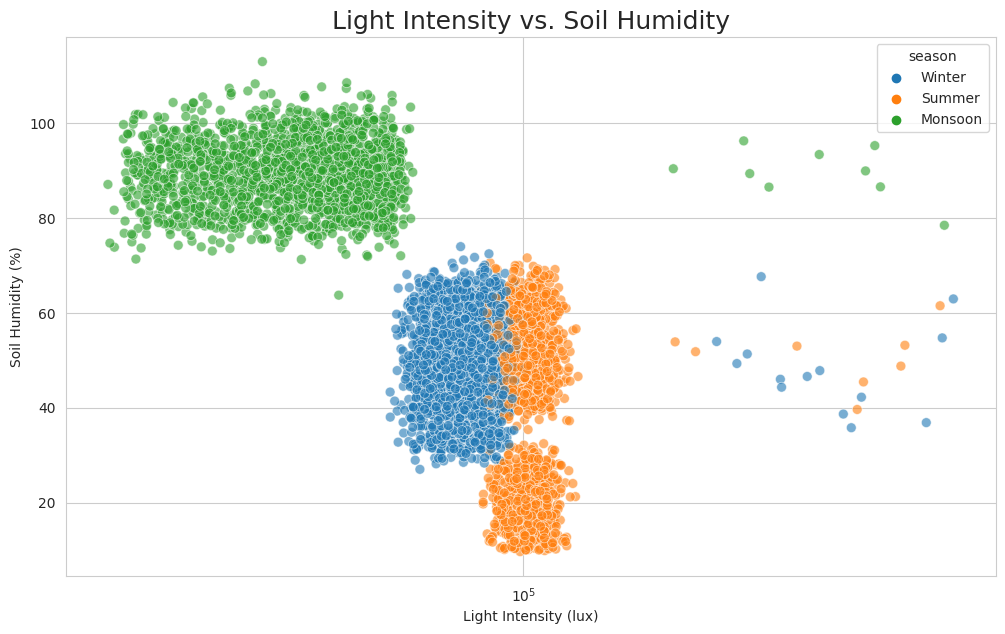

In [ ]:
# Graph 5: Light Intensity vs. Soil Humidity
plt.figure(figsize=(12, 7))
sns.scatterplot(x='Light', y='Soil_Moisture',
                data=df, hue='season', alpha=0.6, s=50)
plt.title('Light Intensity vs. Soil Humidity', fontsize=18)
plt.xlabel('Light Intensity (lux)')
plt.ylabel('Soil Humidity (%)')
plt.xscale('log')  # Use log scale for better visualization of lux
plt.show()

In [ ]:
# Graph 7: pH vs. N-P-K Availability (showing one nutrient)
plt.figure(figsize=(12, 7))
sns.scatterplot(data=df, x='pH', y='P', alpha=0.5, color='purple')
plt.title('Soil pH vs. Available Phosphorus (P)', fontsize=18)
plt.xlabel('pH')
plt.ylabel('Phosphorus (kg/ha)')
plt.show()

In [ ]:
# Graph 8: Pollution Levels by District
plt.figure(figsize=(10, 6))
sns.violinplot(x='district', y='MQ135_CO2', data=df, palette='plasma')
plt.title('Environmental Pollution Distribution by District', fontsize=18)
plt.ylim(0, 300)  # Cap y-axis to focus on the main distribution
plt.show()

In [ ]:
# Graph 9: Altitude vs. Pressure
plt.figure(figsize=(12, 6))
sns.regplot(x='BMP_Altitude', y='BMP_Pressure', data=df,
            scatter_kws={'alpha': 0.2}, line_kws={'color': 'red'})
plt.title('Altitude vs. Atmospheric Pressure', fontsize=18)
plt.xlabel('Altitude (m)')
plt.ylabel('Pressure (hPa)')
plt.show()

In [ ]:
from sklearn.preprocessing import MultiLabelBinarizer
mlb = MultiLabelBinarizer()
labels = df['target_crops'].dropna().astype(str).apply(
    lambda x: [s.strip() for s in x.split(',')])
ymat = mlb.fit_transform(labels)
counts = ymat.sum(axis=0)
plt.figure(figsize=(12, 6))
sns.barplot(x=counts, y=mlb.classes_)
plt.title('Label counts (multilabel target_crops)')
plt.tight_layout()
plt.show()

In [ ]:
# 2. Boxplots to inspect outliers (N,P,K,pH)
plt.figure(figsize=(12, 6))
for i, col in enumerate(['N', 'P', 'K']):
    plt.subplot(1, 3, i+1)
    sns.boxplot(x=df[col])
    plt.title(col+' boxplot')
plt.tight_layout()
plt.show()

In [ ]:
# 4. Scatter plot env_temp vs soil_temp (with season coloring if available)
sns.scatterplot(x='Env_Temp', y='Soil_Temp', hue='season',
                data=df, palette='tab10', alpha=0.6)
plt.title('Env temp vs Soil temp')
plt.tight_layout()
plt.show()

In [ ]:
# 5. Scatter plot env_humidity vs soil_humidity
sns.scatterplot(x='DHT_Humidity',
                y='Soil_Moisture', hue='season', data=df, alpha=0.6)
plt.title('Env humidity vs Soil humidity')
plt.tight_layout()
plt.show()

In [ ]:
# 7. Distribution of env_pollution and env_gasses_co2
plt.figure(figsize=(12, 7))
plt.subplot(1, 2, 1)
sns.histplot(df['MQ135_CO'].dropna(), bins=40)
plt.title('Env pollution CO distribution')
plt.subplot(1, 2, 2)
sns.histplot(df['MQ135_CO2'].dropna(), bins=40)
plt.title('CO2 distribution')
plt.tight_layout()
plt.show()

---
---


## > Data Cleaning

---


In [ ]:
def clean_and_clip(df_in):
    df = df_in.copy()
    # Basic validity checks
    try:
        df.loc[df['P'] < 0, 'P'] = np.nan
    except:
        pass
    try:
        df.loc[df['K'] < 0, 'K'] = np.nan
    except:
        pass
    try:
        df.loc[df['N'] < 0, 'N'] = np.nan
    except:
        pass
    try:
        df.loc[df['Env_Temp'] < 0, 'Env_Temp'] = np.nan
    except:
        pass
    try:
        df.loc[df['DHT_Humidity'] > 100, 'DHT_Humidity'] = np.nan
    except:
        pass
    try:
        df.loc[df['Soil_Moisture'] > 100, 'Soil_Moisture'] = np.nan
    except:
        pass
    try:
        df.loc[df['Light'] < 0, 'Light'] = np.nan
    except:
        pass

    # Outlier removal using IQR method
    for col in df.select_dtypes(include=['float64', 'int64']).columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        df.loc[(df[col] < lower) | (df[col] > upper), col] = np.nan

    return df

In [ ]:
class RobustLocationImputer(BaseEstimator, TransformerMixin):
    def __init__(self, numeric_cols=None, min_group_size=5, verbose=False):
        self.numeric_cols = numeric_cols
        self.min_group_size = min_group_size
        self.verbose = verbose

    def fit(self, X, y=None):
        df = X.copy()
        if self.numeric_cols is None:
            self.numeric_cols = df.select_dtypes(
                include=[np.number]).columns.tolist()

        # Compute medians for each level
        self.group_medians_ = (
            df.groupby(["district", "location", "season"])[self.numeric_cols]
            .median(numeric_only=True)
            .dropna(how="all")
        )
        self.district_medians_ = (
            df.groupby("district")[self.numeric_cols]
            .median(numeric_only=True)
            .dropna(how="all")
        )
        self.global_medians_ = df[self.numeric_cols].median(numeric_only=True)
        return self

    def set_output(self, transform=None):
        return self

    def transform(self, X):
        df = X.copy()
        for idx, row in df.iterrows():
            d, l, s = row["district"], row["location"], row["season"]
            group_key = (d, l, s)
            if group_key in self.group_medians_.index:
                group_valid = (
                    len(df[(df["district"] == d) & (
                        df["location"] == l) & (df["season"] == s)])
                    >= self.min_group_size
                )
            else:
                group_valid = False
            for col in self.numeric_cols:
                if pd.isna(row[col]):
                    new_val = None
                    if group_valid and not pd.isna(self.group_medians_.loc[group_key, col]):
                        new_val = self.group_medians_.loc[group_key, col]
                    elif d in self.district_medians_.index and not pd.isna(self.district_medians_.loc[d, col]):
                        new_val = self.district_medians_.loc[d, col]
                    else:
                        new_val = self.global_medians_[col]
                    df.at[idx, col] = new_val
        return df

---
---


## > Feature Engineering

---


In [ ]:
def feature_engineer(df_in):
    """Add engineered features and return a new DataFrame copy."""
    df = df_in.copy()

    #  Core nutrient ratios
    df['N_plus_P'] = df['N'] + df['P']
    df['P_over_N'] = df['P'] / (df['N'] + 1e-6)
    df['K_over_N'] = df['K'] / (df['N'] + 1e-6)

    #  Temperature deltas
    df['env_minus_soil_temp'] = df['Env_Temp'] - df['Soil_Temp']

    # Soil moisture replaces old soil_humidity_percent
    df['env_minus_soil_humidity'] = df['DHT_Humidity'] - df['Soil_Moisture']

    #  Log transforms
    df['light_log'] = np.log1p(df['Light'])

    df['alt_bucket'] = pd.cut(
        df['BMP_Altitude'],
        bins=[-1, 100, 300, 600, 1000, 5000],
        labels=['very_low', 'low', 'med', 'high', 'very_high']
    )

    season_map = {s.lower(): i for i, s in enumerate(
        ['summer', 'monsoon', 'winter']
    )}
    df['season_enc'] = df['season'].astype(str).str.lower().map(season_map)

    return df

---
---


## > Data Preprocessing

---


In [ ]:
clean_transformer = FunctionTransformer(clean_and_clip, validate=False)
impute_transformer = RobustLocationImputer(verbose=True)
fe_transformer = FunctionTransformer(feature_engineer, validate=False)

df_tmp = feature_engineer(clean_and_clip(df.copy()))

all_numeric = df_tmp.select_dtypes(
    include=['float64', 'int64', 'float32', 'int32']).columns.tolist()
all_categorical = df_tmp.select_dtypes(
    include=['object', 'category']).columns.tolist()

if 'target_crops' in all_categorical:
    all_categorical.remove('target_crops')

print('Numeric features:', all_numeric)
print('Categorical features:', all_categorical)

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse=False))
])

ct = ColumnTransformer(transformers=[
    ('num', numeric_transformer, all_numeric),
    ('cat', categorical_transformer, all_categorical)
], remainder='drop')

preprocessor = Pipeline(steps=[
    ('cleaning', clean_transformer),
    ('robust_impute', impute_transformer),
    ('feature_engineering', fe_transformer),
    ('preprocessor', ct)
]).set_output(transform='pandas')

print("Pipeline created")

In [ ]:
raw_target = df['target_crops']

mlb = MultiLabelBinarizer()
parsed = raw_target.fillna('').astype(str).apply(
    lambda x: [s.strip() for s in x.split(',') if s.strip() != ''])
Y = mlb.fit_transform(parsed)

target_classes = list(mlb.classes_)


joblib.dump(mlb, f"MLB.joblib")
print(f"Multilabel Binarizer saved as MLB.joblib")

print('Multilabel detected with classes:', target_classes)

---
---


## > Train Test Split

---


In [ ]:
X = df.drop(columns=['target_crops'])

X_train, X_test, Y_train, Y_test = train_test_split(X, Y,
                                                    test_size=0.2,
                                                    random_state=42)

print('Train / test shapes:', X_train.shape, X_test.shape)

---
---


## > Pipeline Transformation

---


In [ ]:
X_train_trans = preprocessor.fit_transform(X_train)
X_test_trans = preprocessor.transform(X_test)

joblib.dump(preprocessor, f"preprocessing_pipeline.joblib")
print(f"Pipeline saved as preprocessing_pipeline.joblib")

print('Train / test shapes:', X_train_trans.shape, X_test_trans.shape)

---
---


## > Model Training

---


In [ ]:
crop_list = list(mlb.classes_)
n_labels = len(crop_list)

# ------------------------------------------------------------------
# 1. MAKE RANKING DATA
# ------------------------------------------------------------------
def make_ranking_data(X, Y, crop_list):
    X_rank, y_rank, groups = [], [], []

    for i in range(X.shape[0]):
        x_row = X[i]
        true_labels = Y[i]
        
        for j in range(len(crop_list)):
            crop_id_vec = np.eye(len(crop_list))[j]
            feat = np.concatenate([x_row, crop_id_vec])
            X_rank.append(feat)
            y_rank.append(true_labels[j])

        groups.append(len(crop_list))

    return (
        np.array(X_rank, dtype=np.float32),
        np.array(y_rank, dtype=np.int32),
        np.array(groups, dtype=np.int32)
    )
X_train_np = X_train_trans.to_numpy()
X_test_np  = X_test_trans.to_numpy()

Y_train_np = np.array(Y_train)
Y_test_np  = np.array(Y_test)


X_train_rank, y_train_rank, groups_train = make_ranking_data(X_train_np, Y_train_np, crop_list)
X_test_rank, y_test_rank, groups_test = make_ranking_data(X_test_np, Y_test_np, crop_list)

In [ ]:
# ------------------------------------------------------------------
# 2. TRAIN XGBRANKER
# ------------------------------------------------------------------
ranker = XGBRanker(
    objective='rank:ndcg',
    learning_rate=0.05,
    n_estimators=400,
    max_depth=6,
    subsample=0.9,
    colsample_bytree=0.8,
    random_state=42,
)

ranker.fit(
    X_train_rank,
    y_train_rank,
    group=groups_train,
    verbose=True
)

In [ ]:
# ------------------------------------------------------------------
# 3. PREDICT TOP-K RANKINGS
# ------------------------------------------------------------------
def predict_ranked(X_trans, ranker, crop_list):
    n_samples = X_trans.shape[0]
    n_labels = len(crop_list)
    X_full = []

    for i in range(n_samples):
        x = X_trans[i]
        for j in range(n_labels):
            crop_id_vec = np.eye(n_labels)[j]
            feat = np.concatenate([x, crop_id_vec])
            X_full.append(feat)

    X_full = np.array(X_full, dtype=np.float32)
    scores = ranker.predict(X_full).reshape(n_samples, n_labels)

    ranked = np.argsort(-scores, axis=1)
    return ranked, scores

ranked_idx, scores = predict_ranked(X_test_np, ranker, crop_list)

ranked_crops = [[crop_list[j] for j in row] for row in ranked_idx]

In [ ]:
# ------------------------------------------------------------------
# 4. PREP TRUE MULTI-LABEL SETS
# ------------------------------------------------------------------
true_sets = []
for row in Y_test:
    s = {crop_list[i] for i in range(len(row)) if row[i] == 1}
    true_sets.append(s)

# ------------------------------------------------------------------
# 5. METRICS
# ------------------------------------------------------------------
def hit_at_k(true_sets, ranked_crops, k=3):
    hits = sum(1 for t, r in zip(true_sets, ranked_crops) if len(t.intersection(r[:k])) > 0)
    return hits / len(true_sets)

print("Hit@5:", hit_at_k(true_sets, ranked_crops, 5))

print("LRAP:", label_ranking_average_precision_score(Y_test, scores))

def ndcg_at_k(true_sets, ranked_crops, k=3):
    total = 0
    for t, r in zip(true_sets, ranked_crops):
        dcg = 0
        for i, crop in enumerate(r[:k]):
            rel = 1 if crop in t else 0
            dcg += (2**rel - 1) / math.log2(i + 2)

        rel_count = min(len(t), k)
        idcg = sum(1 / math.log2(i + 2) for i in range(rel_count))
        total += 0 if idcg == 0 else dcg / idcg

    return total / len(true_sets)

print("NDCG@5:", ndcg_at_k(true_sets, ranked_crops, 5))

In [ ]:
import joblib

joblib.dump(ranker, "best_model_XGBRanker.joblib")
print("Ranker saved!")

---
---


## > Performance Measure

---


---
---


## > Hyper Parameter Tuning

---


## > Deployment/Export

---


In [ ]:
# import joblib

# best_model_name = df_test_results.sort_values(
#     by="Accuracy", ascending=False).iloc[0]['Model']
# print("Best model based on Test F1_macro:", best_model_name)

# best_model_name = 'XGBClassifier'

# model_dict = {
#     'LogisticRegression': LogisticRegression(max_iter=500),
#     'DecisionTreeClassifier': DecisionTreeClassifier(),
#     'RandomForestClassifier': RandomForestClassifier(n_estimators=500, n_jobs=-1),
#     'GradientBoostingClassifier': GradientBoostingClassifier(n_estimators=500),
#     'AdaBoostClassifier': AdaBoostClassifier(n_estimators=500),
#     'KNeighborsClassifier': KNeighborsClassifier(n_neighbors=7),
#     'SVC': SVC(probability=True),
#     'XGBClassifier': XGBClassifier(n_estimators=800, n_jobs=-1),
#     'LGBMClassifier': LGBMClassifier(n_estimators=500, n_jobs=-1, verbosity=-1),
# }

# X_full = np.vstack([X_train_trans, X_test_trans])
# Y_full = np.vstack([Y_train, Y_test])

# best_model = MultiOutputClassifier(model_dict[best_model_name], n_jobs=-1)
# best_model.fit(X_full, Y_full)

# joblib.dump(best_model, f"best_model_{best_model_name}.joblib")
# print(f"Model saved as best_model_{best_model_name}.joblib")

---
---
